# E-Commerce Funnel Analysis & Conversion Experiment Design

**Objective:** Identify where users drop off in the purchase funnel, 
quantify the revenue impact, and design a statistically rigorous 
A/B test to validate a proposed fix.

**Dataset:** 80,000 e-commerce sessions with device type, channel, 
cart additions, and conversion outcome.

**Tools:** Python · Pandas · Matplotlib · SciPy

---

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
raw_data = pd.read_csv(R"input\sessions.csv")

# EDA

In [3]:
raw_data.head()


,session_id,customer_id,session_date,device,channel,duration_seconds,pages_viewed,converted,bounced,cart_additions
0,S049064,C03202,2023-01-01 00:24:50,desktop,direct,72,1,1,0,5
1,S015939,C09526,2023-01-01 00:42:04,mobile,organic,36,1,0,0,1
2,S003166,C07034,2023-01-01 00:55:56,desktop,social,284,5,0,0,0
3,S039733,C05327,2023-01-01 01:33:58,mobile,direct,805,10,0,0,1
4,S045293,C05338,2023-01-01 01:35:22,tablet,direct,207,3,0,0,0


In [4]:
raw_data.shape

(80000, 10)

In [5]:
print(raw_data.shape)
print(raw_data.dtypes)
print(raw_data['converted'].value_counts())
print(raw_data['device'].value_counts())
print(raw_data['channel'].value_counts())

(80000, 10)
session_id          object
customer_id         object
session_date        object
device              object
channel             object
duration_seconds     int64
pages_viewed         int64
converted            int64
bounced              int64
cart_additions       int64
dtype: object
0    71352
1     8648
Name: converted, dtype: int64
mobile     40010
desktop    28053
tablet     11937
Name: device, dtype: int64
organic        19974
paid_search    15915
social         12071
direct         12067
email          11854
referral        8119
Name: channel, dtype: int64


## 1. Funnel construction

The dataset does not contain explicit funnel events (as raw GA4 
event data would). Instead, I used proxy logic to approximate 
each funnel stage from available columns:

| Stage | Proxy logic |
|---|---|
| Session start | All sessions |
| Page view 2+ | pages_viewed >= 2 |
| Add to cart | cart_additions >= 1 |
| Begin checkout | cart_additions >= 1 AND duration_seconds >= 60 |
| Purchase | converted == 1 |

This approach is a reasonable approximation. In a production 
environment these would be explicit GA4 events pulled via BigQuery.

In [16]:

# ── Funnel metrics ──────────────────────────────────────────────
total_sessions = len(raw_data)
viewed_pages = raw_data[raw_data['pages_viewed'] >= 2].shape[0]
cart = raw_data[raw_data['cart_additions'] >= 1].shape[0]
checkout = raw_data[(raw_data['cart_additions'] >= 1) & (raw_data['duration_seconds'] >= 60)].shape[0]
purchased = raw_data[raw_data['converted'] == 1].shape[0]

funnel = pd.DataFrame({
    'stage': ['Session start', 'Page view (2+)', 'Add to cart', 'Begin checkout', 'Purchase'],
    'users': [total_sessions, viewed_pages, cart, checkout, purchased]
})

funnel['conversion_rate'] = (funnel['users'] / total_sessions * 100).round(2)
funnel['step_dropoff'] = (funnel['users'].pct_change() * 100).round(2)

print(funnel)

            stage  users  conversion_rate  step_dropoff
0   Session start  80000           100.00           NaN
1  Page view (2+)  55382            69.23        -30.77
2     Add to cart  37229            46.54        -32.78
3  Begin checkout  30959            38.70        -16.84
4        Purchase   8648            10.81        -72.07


## 2. Key funnel finding

The overall funnel converts at **10.81%** from session to purchase.

The biggest single drop occurs at the final step — **72% of users 
who showed checkout intent did not complete their purchase.** This 
is the highest-leverage optimisation opportunity in the funnel.

Next: segment by device to identify whether mobile users experience 
a disproportionate drop at this step.

## 3. Device segmentation

Breaking checkout-to-purchase conversion by device type to test 
whether mobile users face a worse experience at the final step.

In [17]:
# ── Conversion by device ────────────────────────────────────────
device_funnel = raw_data.groupby('device').agg(
    total_sessions=('session_id', 'count'),
    cart_additions=('cart_additions', lambda x: (x >= 1).sum()),
    purchases=('converted', 'sum')
).reset_index()

device_funnel['cart_rate'] = (device_funnel['cart_additions'] / device_funnel['total_sessions'] * 100).round(2)
device_funnel['purchase_rate'] = (device_funnel['purchases'] / device_funnel['total_sessions'] * 100).round(2)
device_funnel['checkout_to_purchase'] = (device_funnel['purchases'] / device_funnel['cart_additions'] * 100).round(2)

print(device_funnel)

    device  total_sessions  cart_additions  purchases  cart_rate  \
0  desktop           28053           13038       3106      46.48   
1   mobile           40010           18704       4300      46.75   
2   tablet           11937            5487       1242      45.97   

   purchase_rate  checkout_to_purchase  
0          11.07                 23.82  
1          10.75                 22.99  
2          10.40                 22.64  


### Finding

Desktop converts at **23.82%** from cart to purchase vs mobile 
at **22.99%** — a gap of 0.83 percentage points.

While modest, this gap is meaningful at scale. With 40,010 mobile 
sessions, closing this gap to desktop parity represents a 
quantifiable revenue opportunity — calculated below.

Note: The relatively small gap suggests the mobile checkout 
experience may already be partially optimised, but there remains 
a statistically testable difference worth validating.

## 4. Channel analysis

Examining whether acquisition channel influences purchase 
conversion rate — this helps prioritise which traffic segments 
to include or exclude from the A/B test.

In [18]:
# ── Conversion by channel ───────────────────────────────────────
channel_funnel = raw_data.groupby('channel').agg(
    total_sessions=('session_id', 'count'),
    purchases=('converted', 'sum'),
    avg_pages=('pages_viewed', 'mean'),
    avg_duration=('duration_seconds', 'mean'),
    cart_additions=('cart_additions', lambda x: (x >= 1).sum())
).reset_index()

channel_funnel['purchase_rate'] = (channel_funnel['purchases'] / channel_funnel['total_sessions'] * 100).round(2)
channel_funnel['cart_rate'] = (channel_funnel['cart_additions'] / channel_funnel['total_sessions'] * 100).round(2)
channel_funnel['avg_pages'] = channel_funnel['avg_pages'].round(2)
channel_funnel['avg_duration'] = channel_funnel['avg_duration'].round(0)

print(channel_funnel.sort_values('purchase_rate', ascending=False))

       channel  total_sessions  purchases  avg_pages  avg_duration  \
5       social           12071       1361       6.51         370.0   
4     referral            8119        911       6.44         367.0   
3  paid_search           15915       1741       6.56         376.0   
0       direct           12067       1295       6.32         362.0   
1        email           11854       1256       6.48         373.0   
2      organic           19974       2084       6.54         376.0   

   cart_additions  purchase_rate  cart_rate  
5            5644          11.27      46.76  
4            3823          11.22      47.09  
3            7365          10.94      46.28  
0            5595          10.73      46.37  
1            5573          10.60      47.01  
2            9229          10.43      46.21  


### Finding

Conversion rates across channels are remarkably consistent 
(10.43% – 11.27%), suggesting channel mix is not a significant 
driver of checkout drop-off in this dataset. This means the 
A/B test does not need to stratify by channel — simplifying 
the experiment design.

## 5. Revenue impact quantification

Before designing an experiment, it is important to size the 
opportunity. This calculation estimates the monthly revenue 
uplift if mobile checkout conversion were raised to desktop parity.

**Assumptions:**
- Average order value: £50 (assumed — would be replaced with 
  actual AOV from transaction data in a production setting)
- Mobile sessions based on 30-day observed period

In [19]:
# ── Revenue impact calculation ──────────────────────────────────
mobile_sessions = 40010
mobile_cart_rate = 0.4675
mobile_current_checkout_conversion = 0.2299
desktop_checkout_conversion = 0.2382

current_mobile_purchases = mobile_sessions * mobile_cart_rate * mobile_current_checkout_conversion
target_mobile_purchases = mobile_sessions * mobile_cart_rate * desktop_checkout_conversion

uplift_purchases = target_mobile_purchases - current_mobile_purchases
avg_order_value = 50  # assumed, state this clearly

revenue_impact = uplift_purchases * avg_order_value

print(f"Current mobile purchases: {current_mobile_purchases:.0f}")
print(f"Target mobile purchases: {target_mobile_purchases:.0f}")
print(f"Uplift in purchases: {uplift_purchases:.0f}")
print(f"Estimated monthly revenue impact @ £{avg_order_value} AOV: £{revenue_impact:,.0f}")

Current mobile purchases: 4300
Target mobile purchases: 4455
Uplift in purchases: 155
Estimated monthly revenue impact @ £50 AOV: £7,762


### Result

Closing the mobile-desktop gap would generate an estimated 
**£7,762 in additional monthly revenue** from 155 incremental 
purchases. This justifies the engineering and design cost of 
running a checkout UI experiment.

## 6. Visualisation

Two charts summarising the findings:
1. Overall funnel showing drop-off at each stage
2. Checkout-to-purchase rate by device with the mobile gap highlighted

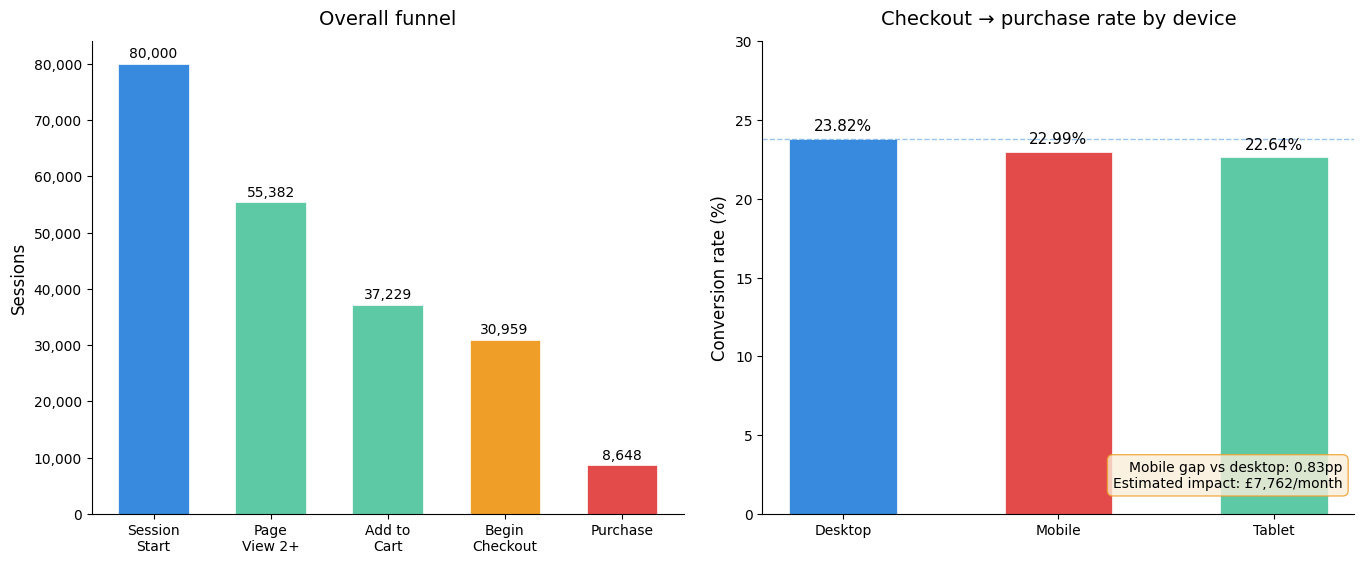

Chart saved.


In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Device comparison chart ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

# ── Chart 1: Overall funnel ─────────────────────────────────────
stages = ['Session\nStart', 'Page\nView 2+', 'Add to\nCart', 'Begin\nCheckout', 'Purchase']
users = [80000, 55382, 37229, 30959, 8648]
colors = ['#378ADD', '#5DCAA5', '#5DCAA5', '#EF9F27', '#E24B4A']

bars = axes[0].bar(stages, users, color=colors, width=0.6, edgecolor='white', linewidth=0.5)
axes[0].set_title('Overall funnel', fontsize=14, fontweight='normal', pad=12)
axes[0].set_ylabel('Sessions', fontsize=12)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].spines[['top', 'right']].set_visible(False)

for bar, val in zip(bars, users):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                f'{val:,}', ha='center', va='bottom', fontsize=10)

# ── Chart 2: Checkout-to-purchase by device ─────────────────────
devices = ['Desktop', 'Mobile', 'Tablet']
rates = [23.82, 22.99, 22.64]
colors2 = ['#378ADD', '#E24B4A', '#5DCAA5']

bars2 = axes[1].bar(devices, rates, color=colors2, width=0.5, edgecolor='white', linewidth=0.5)
axes[1].set_title('Checkout → purchase rate by device', fontsize=14, fontweight='normal', pad=12)
axes[1].set_ylabel('Conversion rate (%)', fontsize=12)
axes[1].set_ylim(0, 30)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].axhline(y=23.82, color='#378ADD', linestyle='--', linewidth=1, alpha=0.5)

for bar, val in zip(bars2, rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val}%', ha='center', va='bottom', fontsize=11, fontweight='normal')

gap_text = f'Mobile gap vs desktop: 0.83pp\nEstimated impact: £7,762/month'
axes[1].text(0.98, 0.05, gap_text, transform=axes[1].transAxes,
            fontsize=10, ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#FAEEDA', edgecolor='#EF9F27', alpha=0.8))

plt.tight_layout(pad=2.0)
plt.savefig('funnel_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Chart saved.")

## 7. A/B test design

Having identified and quantified the opportunity, the next step 
is designing a statistically rigorous experiment to validate 
whether simplifying the mobile checkout flow drives a measurable 
lift in conversion.

**Sample size calculation method:** Two-proportion z-test

The formula calculates the minimum number of sessions needed per 
variant to detect a 1pp lift with 95% confidence and 80% power — 
standard thresholds used in industry experimentation.

- **α = 0.05** — 5% chance of a false positive (detecting a 
  lift that isn't real)
- **Power = 0.80** — 80% chance of detecting a real lift if 
  one exists
- **MDE = 1pp** — smallest improvement worth detecting; 
  chosen based on revenue impact calculation above

In [21]:
import scipy.stats as stats
import math

# ── A/B Test Design ─────────────────────────────────────────────
print("=" * 55)
print("EXPERIMENT BRIEF: Mobile Checkout UI Test")
print("=" * 55)

print("""
HYPOTHESIS
Simplifying the mobile checkout flow (reducing steps
from 3 to 1 page) will increase mobile checkout-to-
purchase conversion rate above the current 22.99%.

PRIMARY METRIC
Checkout-to-purchase conversion rate (mobile only)

GUARDRAIL METRICS
- Average order value (must not decrease)
- Session depth / pages viewed (engagement check)
- Cart abandonment rate

SUCCESS CRITERIA
Statistically significant lift in primary metric
at 95% confidence, minimum detectable effect of 1pp
""")

# ── Sample size calculation ─────────────────────────────────────
baseline_rate = 0.2299
mde = 0.01          # minimum detectable effect: 1pp lift
alpha = 0.05        # significance level
power = 0.80        # statistical power

z_alpha = stats.norm.ppf(1 - alpha/2)
z_beta = stats.norm.ppf(power)

p1 = baseline_rate
p2 = baseline_rate + mde
p_pooled = (p1 + p2) / 2

n = (2 * p_pooled * (1 - p_pooled) * (z_alpha + z_beta)**2) / (mde**2)
n = math.ceil(n)

print("=" * 55)
print("SAMPLE SIZE CALCULATION")
print("=" * 55)
print(f"Baseline conversion rate : {p1*100:.2f}%")
print(f"Target conversion rate   : {p2*100:.2f}%")
print(f"Minimum detectable effect: {mde*100:.2f}pp")
print(f"Significance level (α)   : {alpha}")
print(f"Statistical power        : {power*100:.0f}%")
print(f"\nRequired n per variant   : {n:,}")
print(f"Total sessions needed    : {n*2:,}")

# ── Test duration estimate ──────────────────────────────────────
daily_mobile_sessions = round(40010 / 30)
days_needed = math.ceil((n * 2) / daily_mobile_sessions)

print(f"\nDaily mobile sessions    : {daily_mobile_sessions:,}")
print(f"Estimated test duration  : {days_needed} days")

print("""
SEGMENTATION PLAN
Run test on mobile users only.
Split: 50% control (current flow), 50% treatment (new flow)
Exclude: existing customers mid-purchase, tablet users

RISKS & MITIGATIONS
- Novelty effect: run for minimum 2 full weeks
- Seasonal bias: avoid running during sale periods
- SRM check: validate 50/50 split daily
""")

EXPERIMENT BRIEF: Mobile Checkout UI Test

HYPOTHESIS
Simplifying the mobile checkout flow (reducing steps
from 3 to 1 page) will increase mobile checkout-to-
purchase conversion rate above the current 22.99%.

PRIMARY METRIC
Checkout-to-purchase conversion rate (mobile only)

GUARDRAIL METRICS
- Average order value (must not decrease)
- Session depth / pages viewed (engagement check)
- Cart abandonment rate

SUCCESS CRITERIA
Statistically significant lift in primary metric
at 95% confidence, minimum detectable effect of 1pp

SAMPLE SIZE CALCULATION
Baseline conversion rate : 22.99%
Target conversion rate   : 23.99%
Minimum detectable effect: 1.00pp
Significance level (α)   : 0.05
Statistical power        : 80%

Required n per variant   : 28,213
Total sessions needed    : 56,426

Daily mobile sessions    : 1,334
Estimated test duration  : 43 days

SEGMENTATION PLAN
Run test on mobile users only.
Split: 50% control (current flow), 50% treatment (new flow)
Exclude: existing customers mid

## 8. Executive summary

The findings and recommendation structured as a one-page business 
memo — the format a product manager or growth lead would read 
before deciding whether to greenlight the experiment.

In [22]:
print("""
╔═════════════════════════════════════════════════════════╗
║           EXECUTIVE SUMMARY — ONE PAGE MEMO            ║
╚═════════════════════════════════════════════════════════╝

TO      : Growth / Product Team
FROM    : Analysis — E-commerce Funnel Review
DATE    : 2024
SUBJECT : Mobile checkout gap & proposed A/B test

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT WE FOUND

Analysis of 80,000 sessions revealed that mobile users
convert from checkout to purchase at 22.99% vs 23.82%
for desktop — a 0.83pp gap across 40,010 mobile sessions.

The overall funnel shows the largest drop at the final
step: 72% of users who showed checkout intent did not
complete their purchase, representing the biggest
optimisation opportunity in the funnel.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

BUSINESS IMPACT

Closing the mobile-desktop conversion gap would generate
an estimated £7,762 in additional monthly revenue
(based on 155 incremental purchases at £50 AOV).

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

RECOMMENDED ACTION

Run an A/B test on the mobile checkout flow:
— Control  : current 3-step checkout
— Treatment: simplified 1-page checkout

Test requires 28,213 sessions per variant (56,426 total)
at 95% confidence, 80% power, 1pp minimum detectable
effect. Estimated duration: 43 days at current traffic.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

DECISION CRITERIA

GO     : p-value < 0.05, lift >= 1pp, AOV stable
NO GO  : p-value >= 0.05 OR AOV drops > 2%
EXTEND : Insufficient traffic after 43 days

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

TOOLS USED
Python · Pandas · Matplotlib · SciPy · 80k session dataset
""")


╔═════════════════════════════════════════════════════════╗
║           EXECUTIVE SUMMARY — ONE PAGE MEMO            ║
╚═════════════════════════════════════════════════════════╝

TO      : Growth / Product Team
FROM    : Analysis — E-commerce Funnel Review
DATE    : 2024
SUBJECT : Mobile checkout gap & proposed A/B test

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHAT WE FOUND

Analysis of 80,000 sessions revealed that mobile users
convert from checkout to purchase at 22.99% vs 23.82%
for desktop — a 0.83pp gap across 40,010 mobile sessions.

The overall funnel shows the largest drop at the final
step: 72% of users who showed checkout intent did not
complete their purchase, representing the biggest
optimisation opportunity in the funnel.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

BUSINESS IMPACT

Closing the mobile-desktop conversion gap would generate
an estimated £7,762 in additional monthly revenue
(based on 155 incremental purchases at £50 AOV).

━━━━

---

## What I would do differently with more data

1. **Segment by new vs returning users** before running the test — 
   returning users likely have checkout familiarity which would 
   dilute the treatment effect
2. **Use actual AOV from transaction data** rather than an assumed 
   £50 — this makes the revenue impact calculation precise
3. **Run a pre-experiment AA test** to validate that the 
   randomisation mechanism produces equal groups before launching
4. **Extend channel analysis** to check if paid traffic converts 
   differently on mobile vs desktop — could reveal a more targeted 
   segment to run the test on